<h2>Taxi Simulator</h2>

<h2>User Registration</h2>

First, we are registering User by calling UserRegistration API ...

Created by Kirti Holkar

In [60]:
import pandas as pd
import requests
import json
class UserDTO:
   def __init__(self, **kwargs):
       self.name = kwargs.get("name")
       self.email = kwargs.get("email")
       self.phone = kwargs.get("phone")
       self.location = kwargs.get("location")
       self.preferred_taxi_type = kwargs.get("preferred_taxi_type")
       
   def to_dict(self):
       return self.__dict__
   
   @classmethod
   def from_dict(cls, dict_obj):
       return cls(**dict_obj)

def make_userapi_call(userdata: UserDTO):
  api_url = "https://uo86pj72hk.execute-api.us-east-1.amazonaws.com/SIT/UserRegistration"
  payload = {
  "name": userdata.name,
  "email": userdata.email,
  "phone": userdata.phone,
  "location": userdata.location,
  "preferred_taxi_type": userdata.preferred_taxi_type}
  headers =  {"Content-Type":"application/json"}
  response = requests.post(api_url, data=json.dumps(payload), headers=headers)
  if response.status_code == 200:
        response.json()
        print(f"Successfully created user : {response.json()}")
        response_dict_user = json.loads(response.text) 
        print(response_dict_user['body'])  
  else:
        print(f"Failed to create user. Status Code: {response.status_code}")
        
if __name__ == "__main__":
  user_dto = UserDTO.from_dict({
  "name": "Kirti",
  "email": "kirti14holkar@gmail.com",
  "phone": "9754895223",
  "location": {
    "lat": 13.13,
    "lng": 77.62
  },
  "preferred_taxi_type": "economy"
  })
  make_userapi_call(user_dto)

Successfully created user : {'statusCode': 200, 'body': '{"UserId": "aa08c043-6689-471c-8ed9-68e1244275a9"}'}
{"UserId": "aa08c043-6689-471c-8ed9-68e1244275a9"}


<h2>Taxi Registration</h2>

we are registering taxi by calling TaxiRegistration API ...

In [61]:
import requests
import json

class TaxiDTO:
   def __init__(self, **kwargs):
       self.driver_name = kwargs.get("driver_name")
       self.license_plate = kwargs.get("license_plate")
       self.email = kwargs.get("email")
       self.phone = kwargs.get("phone")
       self.location = kwargs.get("location")
       self.taxi_type = kwargs.get("taxi_type")
       
   def to_dict(self):
       return self.__dict__
   
   @classmethod
   def from_dict(cls, dict_obj):
       return cls(**dict_obj)
   
def taxireg_api_call(taxidata:TaxiDTO):
  api_url = "https://uo86pj72hk.execute-api.us-east-1.amazonaws.com/SIT/taxiRegistration"
  payload = {
  "driver_name": taxidata.driver_name,
  "license_plate": taxidata.license_plate,
  "email": taxidata.email,
  "phone": taxidata.phone,
  "location": taxidata.location,
  "taxi_type": taxidata.taxi_type
  }       

  headers =  {"Content-Type":"application/json"}
  # Make a GET request to the API endpoint using requests.post()
  response = requests.post(api_url, data=json.dumps(payload), headers=headers)
  if response.status_code == 200:
        response.json()
        print(f"Successfully created taxi : {response.json()}")     
  else:
        print(f"Failed to create taxi. Status Code: {response.status_code}")
        
if __name__ == "__main__":
    taxi_dto = TaxiDTO.from_dict({
    "name": "Kirti",
    "email": "kirti14holkar@gmail.com",
    "phone": "9545706763",
    "location": {
      "lat": 13.13,
      "lng": 77.62
    },
   "preferred_taxi_type": "economy"
    })
    taxireg_api_call(taxi_dto)

Successfully created taxi : {'statusCode': 200, 'body': '{"TaxiId": "76480566-889a-4be9-9fb5-5b70687cdc79"}'}


<h2>Fetch Taxi</h2>

we are fetching taxi by calling fetchAvailableTaxi API ...

Successfully fetched available taxi: {'statusCode': 200, 'body': [{'taxi_id': 'taxi001', 'geo_location': {'type': 'Point', 'coordinates': [77.7, 13.15]}, 'driver_name': 'John Doe', 'license_plate': 'ABC123', 'last_service_date': '2024-01-15'}, {'taxi_id': 'taxi002', 'geo_location': {'type': 'Point', 'coordinates': [77.71, 13.12]}, 'driver_name': 'Jane Smith', 'license_plate': 'XYZ789', 'last_service_date': '2024-02-20'}]}
   taxi_id driver_name license_plate last_service_date   type     coordinates
0  taxi001    John Doe        ABC123        2024-01-15  Point   [77.7, 13.15]
1  taxi002  Jane Smith        XYZ789        2024-02-20  Point  [77.71, 13.12]
['taxi001', 'taxi002']


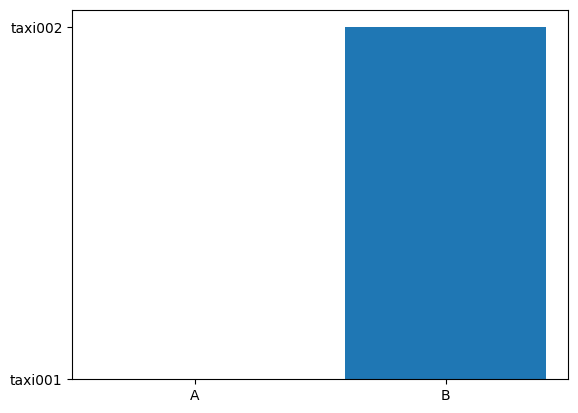

In [71]:
import pandas as pd
import requests
import json
import matplotlib.pyplot as plt
import numpy as np
class FetchTaxiDTO:
   def __init__(self, **kwargs):
       self.user_location = kwargs.get("user_location")
       self.taxi_type = kwargs.get("taxi_type")
       
   def to_dict(self):
       return self.__dict__
   
   @classmethod
   def from_dict(cls, dict_obj):
       return cls(**dict_obj)
   
#Function created to fetch available taxi
def fetchtaxi_api_call(fetchtaxidata: FetchTaxiDTO):
  api_url = "https://uo86pj72hk.execute-api.us-east-1.amazonaws.com/SIT/fetchAvailableTaxi"
  payload = {
   "user_location": fetchtaxidata.user_location,
   "taxi_type": fetchtaxidata.taxi_type
     }

  headers =  {"Content-Type":"application/json"}
  response = requests.post(api_url, data=json.dumps(payload), headers=headers)
  response.json()
  print(f"Successfully fetched available taxi: {response.json()}")     
  response_dict = json.loads(response.text)
  for i in response_dict:
         taxi_details=response_dict['body']
         #print(f"Available Taxis ::::{taxi_details}")
         data = pd.DataFrame(taxi_details)
         data.head()

  geo_location = pd.DataFrame(line for line in data['geo_location'])
  all_data = pd.merge(data, geo_location, left_index=True, right_index=True)
  all_data.drop(['geo_location'],axis = 1, inplace=True)
  print(all_data.head())
  taxis = list(set(data['taxi_id']))
  print(taxis)
  
  # Make a random dataset:
  taxi_x = taxis
  bars = ('A', 'B')
  y_pos = np.arange(len(bars))

  # Create bars
  plt.bar(y_pos, taxi_x)

  # Create names on the x-axis
  plt.xticks(y_pos, bars)

  # Show graphic
  plt.show()  
if __name__ == "__main__":
    fetchtaxi_data = FetchTaxiDTO.from_dict({
    "user_location": {
    "lat": 13.13,
    "lng": 77.62
    },
    "taxi_type": "economy"
    })
fetchtaxi_api_call(fetchtaxi_data)

<h2>Book Taxi</h2>

we are fetching taxi by calling BookTaxi API ...

In [72]:
import requests
import json
class BookTaxiDTO:
   def __init__(self, **kwargs):
       self.user_id = kwargs.get("user_id")
       self.taxi_id = kwargs.get("taxi_id")
       self.pickup_location = kwargs.get("pickup_location")
       self.dropoff_location = kwargs.get("dropoff_location")
       self.taxi_type = kwargs.get("taxi_type")
       
   def to_dict(self):
       return self.__dict__
   
   @classmethod
   def from_dict(cls, dict_obj):
       return cls(**dict_obj)
   
def booktaxi_api_call(bookTaxidata: BookTaxiDTO):
  api_url = "https://uo86pj72hk.execute-api.us-east-1.amazonaws.com/SIT/BookTaxi"
  payload = {
  "user_id": bookTaxidata.user_id,
  "taxi_id": bookTaxidata.taxi_id,
  "pickup_location": bookTaxidata.pickup_location,
  "dropoff_location": bookTaxidata.pickup_location,
  "taxi_type": bookTaxidata.taxi_type}

  headers =  {"Content-Type":"application/json"}
  response = requests.post(api_url, data=json.dumps(payload), headers=headers)
  if response.status_code == 200:
        response.json()
        print(f"Successfully booked the taxi: {response.json()}")     
  else:
        print(f"Failed to booked the taxi. Status Code: {response.status_code}")

if __name__ == "__main__":
    bookingdata = BookTaxiDTO.from_dict({
     "user_id": "user001",
     "taxi_id": "taxi001",
     "pickup_location": {
       "lat": 13.13,
       "lng": 77.62
      },
     "dropoff_location": {
       "lat": 13.135,
       "lng": 77.625
      },
    "taxi_type": "economy"})
    booktaxi_api_call(bookingdata)

Successfully booked the taxi: {'statusCode': 200, 'body': 'Successfully booked taxi with ID taxi001.'}


<h2>Generate Location</h2>

we are generating location by calling GenerateLocation API ...

In [59]:
import requests
import json

def generatelocation_api_call():
  api_url = "https://uo86pj72hk.execute-api.us-east-1.amazonaws.com/SIT/GenerateLocation"
  payload = {
  }

  headers =  {"Content-Type":"application/json"}
  response = requests.get(api_url, data=json.dumps(payload), headers=headers)
  if response.status_code == 200:
        data=response.json()
        #latitude = data['body'][0]['geometry']['location']['lat']
        #longitude = data['random_location'][0]['geometry']['location']['lng']
        print(f"Successfully Generated location: {response.json()}")     
  else:
        print(f"Failed to Generate location. Status Code: {response.status_code}")

if __name__ == "__main__":
    generatelocation_api_call()

Successfully Generated location: {'statusCode': 200, 'body': '{"random_location": {"lat": 13.072077578213365, "lng": 77.69179879069864}}'}
